In [58]:
#Importando as bibliotecas que serão utilizadas
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np 
from scipy import stats

In [59]:
df = pd.read_csv(r'C:\Users\iago_\projeto_integrado_Sprint6\games.csv') #lendo o arquivo csv e criando um dataframe
df.head(10) #imprimindo as 10 primeiras linhas para ter as primeiras impressões do df

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [60]:
novas_colunas =  []
for novo in df:
    novo_strip =  novo.strip()
    novo_lower = novo_strip.lower()
    novo_replace = novo_lower.replace('_', '')
    novas_colunas.append(novo_lower)

df.columns = novas_colunas

#utilizando ciclo for para ajustar os nomes das colunas de uma forma automatizada. 

df.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  str    
 10  rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 2.0 MB


Analisando o df.info () temos alguns pontos importantes como o valores ausentes e algumas colunas e ate mesmo a necessidade de alteração do tipo do dado
para uma analise mais clara e concreta.

In [62]:
#tratando os dados ausentes
df['name'] = df['name'].fillna('desconhecido')
df['genre']= df['genre'].fillna('desconhecido')
df['rating'] = df['rating'].fillna('desconhecido')
df.info()

#há dados ausentes nas colunas year_of_release, critic_score, user_score porem decidi deixar com valores ausentes nan para nao alterar o tipo do dado
#tendo em vista que precisarei fazer calculos decidi não alterar ou colocar valores como '0' por exemplo que influenciariam na analise futuramente

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  float64
 3   genre            16715 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  str    
 10  rating           16715 non-null  str    
dtypes: float64(6), str(5)
memory usage: 2.1 MB


In [63]:
#alterando o tipo de dado das colunas (consultando um valor unico na coluna user_score)
df['user_score'].unique()

<ArrowStringArray>
[  '8',   nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4', '8.2',
   '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2', '8.9', '6.4',
 '7.8', '7.5', '2.6', '7.2', '9.2',   '7', '7.3', '4.3', '7.6', '5.7',   '5',
 '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8', '6.1', '6.7', '5.4',   '4',
 '4.9', '4.5', '9.3', '6.2', '4.2',   '6', '3.7', '4.1', '5.8', '5.6', '5.5',
 '4.4', '4.6', '5.9', '3.9', '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5',
 '2.5', '1.9',   '3', '2.7', '2.2',   '2', '9.5', '2.1', '3.6', '2.8', '1.8',
 '3.8',   '0', '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
 '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9',   '1', '9.7']
Length: 97, dtype: str

In [64]:
df['user_score'] = df['user_score'].replace('tbd', np.nan) #transformando o valor 'tbd' em um valor nan

In [65]:
#alterando o tipo de dado das colunas
df['year_of_release'] = df['year_of_release'].astype('Int64')
df['user_score'] = df['user_score'].astype('float64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16715 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  str    
dtypes: Int64(1), float64(6), str(4)
memory usage: 2.0 MB


In [66]:
df.duplicated().sum()
#sem dados duplicados

np.int64(0)

In [67]:
df['total_sales'] = (
    df['na_sales']
    + df['eu_sales']
    + df['jp_sales']
    + df['other_sales']
)
#criando coluna que me da o total de vendas do jogo nos países

In [68]:
df.head(20)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,desconhecido,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,desconhecido,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,desconhecido,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,desconhecido,28.31


In [69]:
df_vendas_na =  df['na_sales'].sum()
df_vendas_eu =  df['eu_sales'].sum()
df_vendas_jp =  df['jp_sales'].sum()
df_vendas_others = df['other_sales'].sum()
print(f'o total de vendas na NA é:', df_vendas_na)
print(f'o total de vendas na EU é:', df_vendas_eu)
print(f'o total de vendas na JP é:', df_vendas_jp)
print(f'o total de vendas na Other é:', df_vendas_others)

o total de vendas na NA é: 4402.349999999999
o total de vendas na EU é: 2424.67
o total de vendas na JP é: 1297.37
o total de vendas na Other é: 791.32


In [70]:
df_agrupado_na = df.groupby('platform')['na_sales'].sum()
df_agrupado_na

platform
2600     90.60
3DO       0.00
3DS      83.49
DC        5.43
DS      382.40
GB      114.32
GBA     187.54
GC      133.46
GEN      21.05
GG        0.00
N64     139.02
NES     125.94
NG        0.00
PC       94.53
PCFX      0.00
PS      336.52
PS2     583.84
PS3     393.49
PS4     108.74
PSP     109.17
PSV      12.58
SAT       0.72
SCD       1.00
SNES     61.23
TG16      0.00
WS        0.00
Wii     496.90
WiiU     38.10
X360    602.47
XB      186.69
XOne     93.12
Name: na_sales, dtype: float64

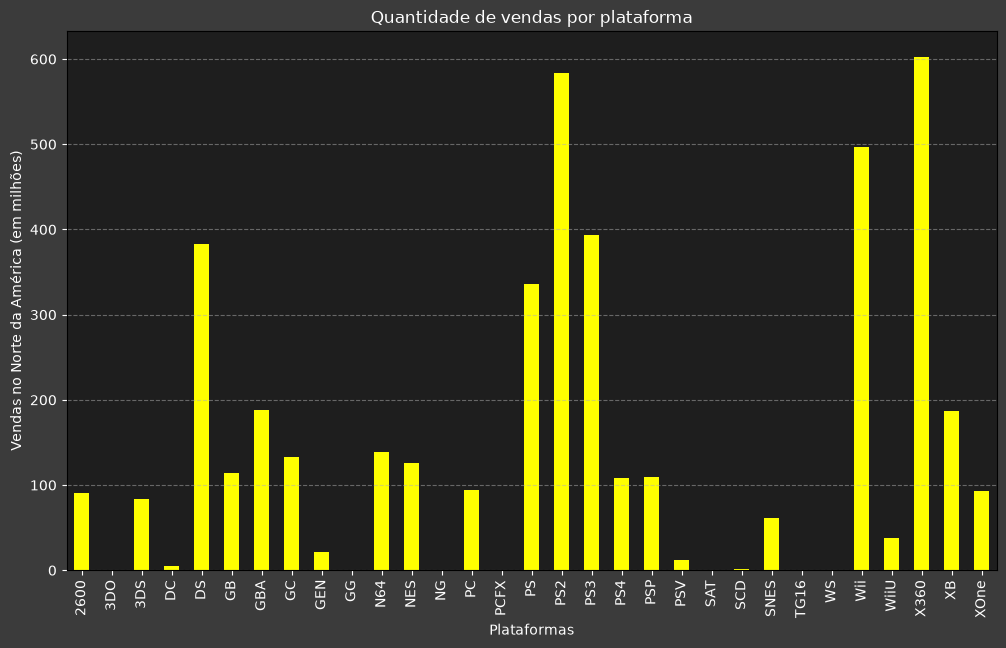

In [71]:
#Gráfico de barras para demonstrar quais foram as plataformas dos jogos mais vendidos no NA
grafico = df_agrupado_na.plot(
    x='platform',
    y='na_sales',
    kind='bar',
    figsize=(12, 7),
    color='yellow',
    xlabel='Plataformas',
    ylabel='Vendas no Norte da América (em milhões)',
    title='Quantidade de vendas por plataforma'
)

grafico.grid(axis='y', linestyle='--', alpha=0.5)
grafico.set_facecolor('#1e1e1e')          # fundo interno escuro
grafico.figure.set_facecolor("#3b3b3b")
grafico.tick_params(colors='white')       # cor dos números dos eixos
grafico.xaxis.label.set_color('white')
grafico.yaxis.label.set_color('white')
grafico.title.set_color('white')
plt.show()

Ate aqui analisamos a performance das plataformas com o historico completo e percebemos através do grafico de barras quais se destacaram. Agora vamos analisar como vai se comportar atraves do tempo se no momento estas são os lideres em vendas ou não. 

In [72]:
jogos_por_ano = df['year_of_release'].value_counts().sort_index()
jogos_por_ano.describe()

count          37.0
mean     444.486486
std      451.557159
min             9.0
25%            36.0
50%           338.0
75%           762.0
max          1427.0
Name: count, dtype: Float64

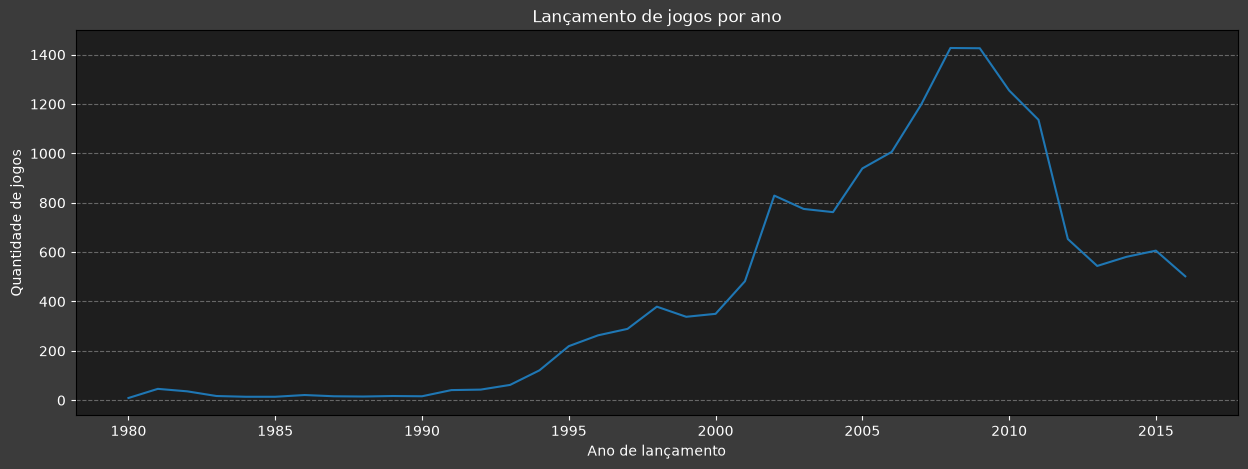

In [73]:
#Primeiro vamos analisar a quantidade de lançamento de jogos por ano para termos noção de como se comporta a industria ao longo dos anos.
graf_lçmt_por_ano = jogos_por_ano.plot(kind='line', 
                                       title='Lançamento de jogos por ano', 
                                       xlabel='Ano de lançamento',
                                       ylabel='Quantidade de jogos',
                                       figsize=[15, 5]
                                       )
graf_lçmt_por_ano.grid(axis='y', linestyle='--', alpha=0.5)
graf_lçmt_por_ano.set_facecolor('#1e1e1e')          
graf_lçmt_por_ano.figure.set_facecolor("#3b3b3b")
graf_lçmt_por_ano.tick_params(colors='white')       
graf_lçmt_por_ano.xaxis.label.set_color('white')
graf_lçmt_por_ano.yaxis.label.set_color('white')
graf_lçmt_por_ano.title.set_color('white')
plt.show()

O lançamento de jogos teve um aumento significativo ao longo dos anos. Mas viveu e vive uma queda onde esta diminuindo a quantidade de lançamentos de jogos por anos. 

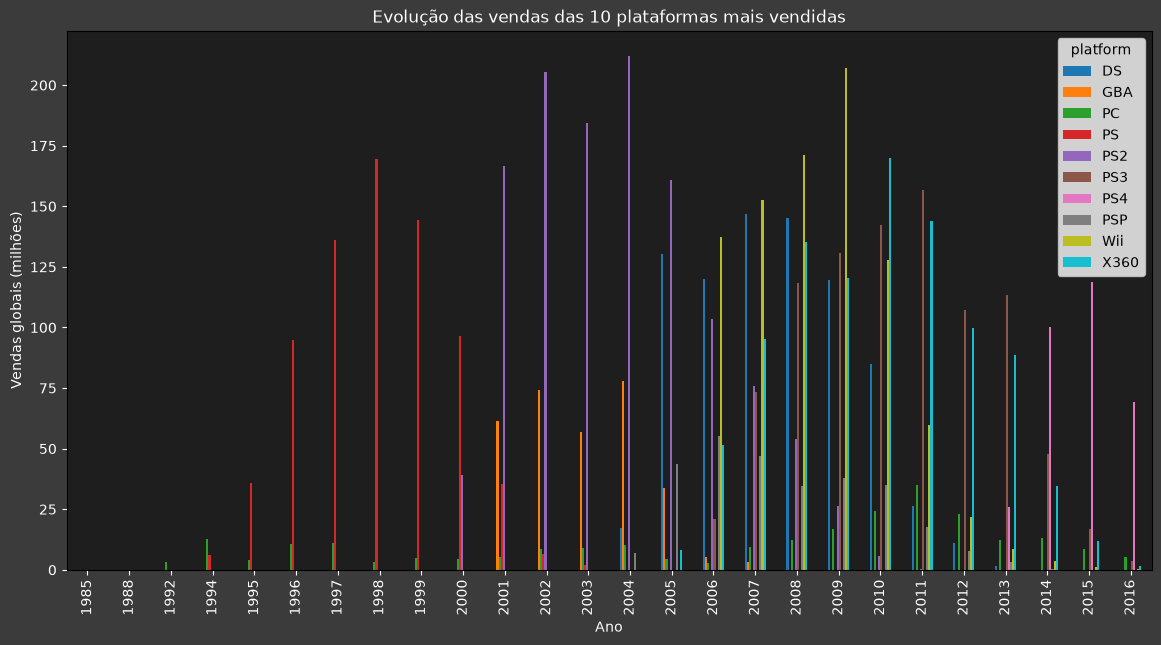

In [74]:
#Vamos ver como as plataformas se comportam ao longo dos anos e ver se na primeira analise do grafico de barras de vendas NA reflete nos dias atuais
#pra isso e necessario agrupar por ano, plataforma e contar o total de vendas.
vendas_por_ano_plataforma = (
    df.groupby(['year_of_release', 'platform'])['total_sales']
      .sum()
      .reset_index()
)

grafico_dados = vendas_por_ano_plataforma.pivot( #Necessário realizar o metodo pivot para poder fazer com que cada barra seja uma plataforma
    index='year_of_release',
    columns='platform',
    values='total_sales'
)

top_plataformas = ( #agrupamos as melhores plataformas as 10 melhores nos ultimos anos para facilitar a visualização do grafico.
    df.groupby('platform')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

dados_top = vendas_por_ano_plataforma[
    vendas_por_ano_plataforma['platform'].isin(top_plataformas)
]

grafico_dados = dados_top.pivot(
    index='year_of_release',
    columns='platform',
    values='total_sales'
)

grafico_evolução = grafico_dados.plot(kind='bar', figsize=(14, 7), colormap='tab10')
plt.xlabel('Ano')
plt.ylabel('Vendas globais (milhões)')
plt.title('Evolução das vendas das 10 plataformas mais vendidas')
#plt.grid(axis='y', linestyle='--', alpha=0.5)

grafico_evolução.set_facecolor('#1e1e1e')          
grafico_evolução.figure.set_facecolor("#3b3b3b")
grafico_evolução.tick_params(colors='white')       
grafico_evolução.xaxis.label.set_color('white')
grafico_evolução.yaxis.label.set_color('white')
grafico_evolução.title.set_color('white')
plt.show()


Ao observarmos o grafico de vendas das 10 plataformas mais vendidas nos ultimos anos vemos que em media as plataformas tem uma boa performance durante 4 anos ate que comecem a reduzir a quantidade de vendas de forma significativa. Também vemos que o grafico de vendas NA que mostra o PS2 e XBOX como principais destaques em vendas podemos ver que no cenario atual não é isso que esta acontecendo.

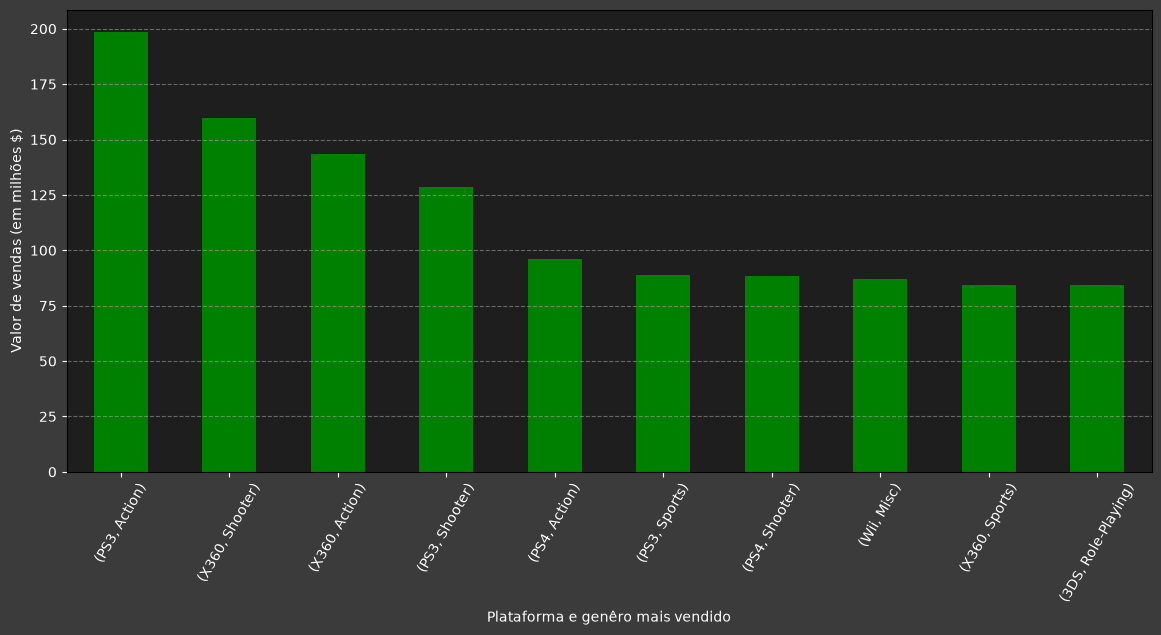

In [75]:
#criando um df filtrado com o perido relevante para analise para campanha pro proximo ano, vamos utilizar dados dos ultimos 6 anos. 
df_atual_filter = df[
    (df['year_of_release'] >= 2010) &
    (df['year_of_release'] <= 2016)
].copy()

top_plataformas_atual = (
    df_atual_filter.groupby(['platform', 'genre', ])['total_sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

grafico_plataforma = top_plataformas_atual.plot(kind='bar', figsize=[14, 6],
                                                rot=60, xlabel='Plataforma e genêro mais vendido',
                                               ylabel='Valor de vendas (em milhões $)', color='green')
grafico_plataforma.grid(axis='y', linestyle='--', alpha=0.5)
grafico_plataforma.set_facecolor('#1e1e1e')          
grafico_plataforma.figure.set_facecolor("#3b3b3b")
grafico_plataforma.tick_params(colors='white')       
grafico_plataforma.xaxis.label.set_color('white')
grafico_plataforma.yaxis.label.set_color('white')
grafico_plataforma.title.set_color('white')


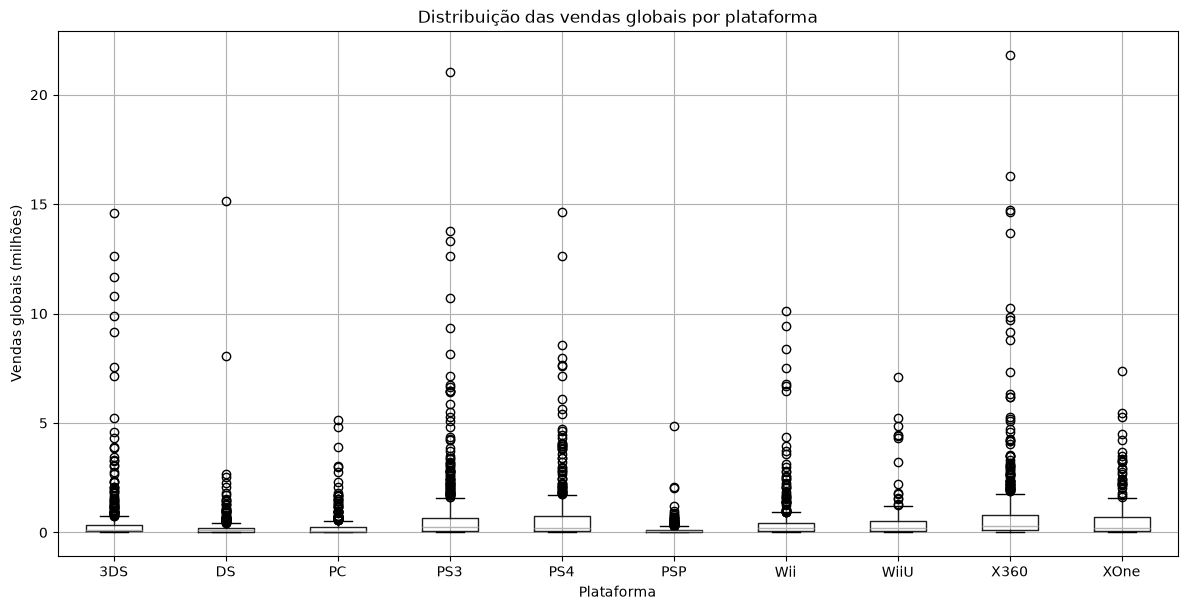

In [76]:
top_plataformas = (
    df_atual_filter.groupby('platform')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

dados_boxplot = df_atual_filter[df_atual_filter['platform'].isin(top_plataformas)]

dados_boxplot.boxplot(
    column='total_sales',
    by='platform',
    figsize=(14, 7)
)

plt.title('Distribuição das vendas globais por plataforma')
plt.suptitle('')  # remove título automático extra
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')
plt.show()

Nessa primeira configuração é possivel perceber valores atipicos nas principais plataformas como PS3 e X360. Irei limitar o eixo y para até 3mm para poder ter uma visão mais clara.

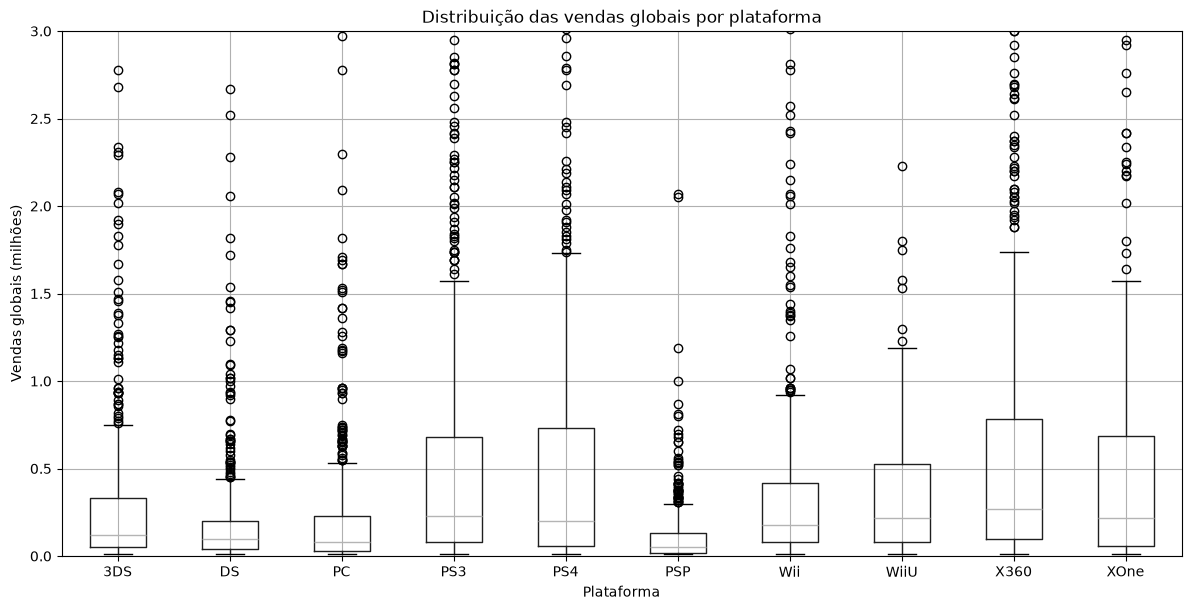

In [77]:
dados_boxplot.boxplot(
    column='total_sales',
    by='platform',
    figsize=(14, 7)
)

plt.title('Distribuição das vendas globais por plataforma')
plt.suptitle('')  # remove título automático extra
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')
plt.ylim(0, 3)
plt.show()

Ao limitar o gráfico para visualizar melhor as vendas abaixo de 3 milhões, observa-se que X360, PS4, PS3 e XOne possuem as maiores medianas e maior dispersão nas vendas globais isso sugere que seus jogos, em geral, alcançam vendas mais altas. Porem os jogos em sua maioria tem sua concentração de vendas aproximadamente 1mm, e conta com alguns jogos com sucesso em vendas que eleva numeros como vimos no grafico anterior. Acredito ser a melhor opção olhar com atenção para o generos que alcançam tanto sucesso.

In [78]:
plataformas_escolhidas = ['X360', 'PS3', 'PS4']

df_por_genero = (
    df_atual_filter[
        df_atual_filter['platform'].isin(plataformas_escolhidas)
    ]
    .groupby(['platform', 'genre'])['total_sales']
    .count()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)

df_por_genero #Contando quantos jogos de cada genero e plataforma foram lançados.

,platform,genre,total_sales
0,PS3,Action,276
1,X360,Action,188
2,PS4,Action,144
3,PS3,Sports,127
4,X360,Sports,108
5,X360,Shooter,108
6,PS3,Shooter,97


In [79]:
plataformas_escolhidas = ['X360', 'PS3', 'PS4']

df_por_genero_soma = (
    df_atual_filter[
        df_atual_filter['platform'].isin(plataformas_escolhidas)
    ]
    .groupby(['platform', 'genre'])['total_sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print(df_por_genero_soma[df_por_genero_soma['platform'] == 'PS3'])

   platform         genre  total_sales
0       PS3        Action       198.60
3       PS3       Shooter       128.36
5       PS3        Sports        88.68
10      PS3  Role-Playing        49.99
12      PS3        Racing        37.29
14      PS3      Fighting        26.75
16      PS3          Misc        20.46
18      PS3     Adventure        16.06
19      PS3      Platform        12.98
27      PS3    Simulation         6.00
29      PS3      Strategy         2.53
33      PS3        Puzzle         0.04


In [80]:
plataformas_escolhidas = ['X360', 'PS3', 'PS4']

df_por_genero_soma = (
    df_atual_filter[
        df_atual_filter['platform'].isin(plataformas_escolhidas)
    ]
    .groupby(['platform', 'genre'])['total_sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print(df_por_genero_soma[df_por_genero_soma['platform'] == 'PS4'])

   platform         genre  total_sales
4       PS4        Action        96.10
6       PS4       Shooter        88.56
9       PS4        Sports        55.61
13      PS4  Role-Playing        28.99
20      PS4        Racing        12.14
21      PS4      Fighting         8.65
22      PS4          Misc         8.19
23      PS4      Platform         7.69
26      PS4     Adventure         6.34
31      PS4    Simulation         1.23
32      PS4      Strategy         0.62
34      PS4        Puzzle         0.02


In [81]:
plataformas_escolhidas = ['X360', 'PS3', 'PS4']

df_por_genero_soma = (
    df_atual_filter[
        df_atual_filter['platform'].isin(plataformas_escolhidas)
    ]
    .groupby(['platform', 'genre'])['total_sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print(df_por_genero_soma[df_por_genero_soma['platform'] == 'X360'])

   platform         genre  total_sales
1      X360       Shooter       159.70
2      X360        Action       143.26
7      X360        Sports        84.26
8      X360          Misc        60.42
11     X360  Role-Playing        37.78
15     X360        Racing        26.11
17     X360      Fighting        17.11
24     X360     Adventure         7.62
25     X360    Simulation         7.41
28     X360      Platform         4.73
30     X360      Strategy         2.01


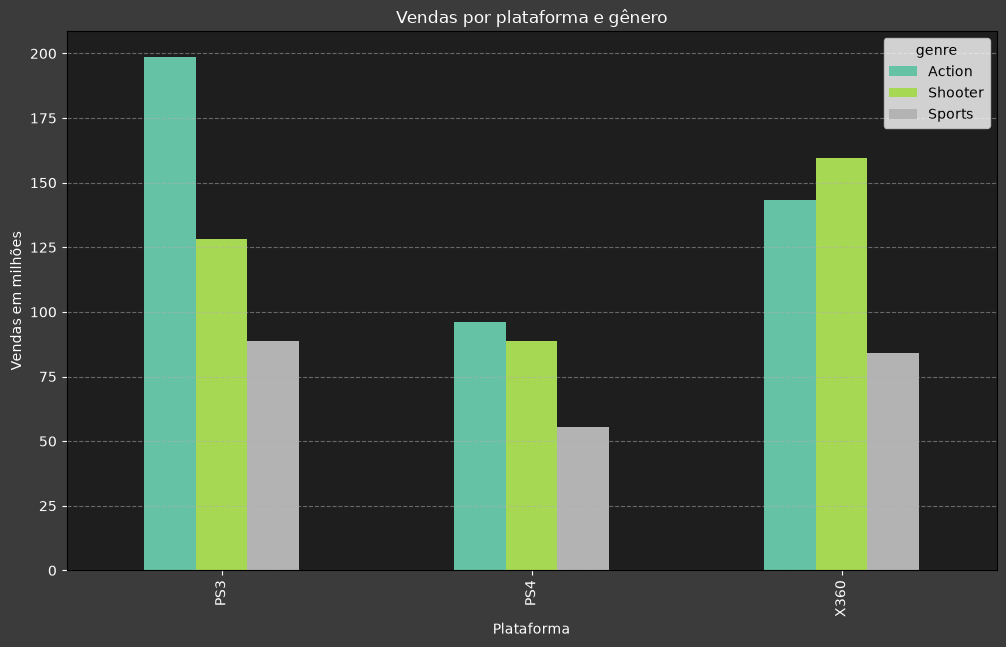

In [88]:
top_3_generos = (
    df_atual_filter.groupby('genre')['total_sales']
      .sum()
      .nlargest(3)
      .index
)

plataformas = ['X360', 'PS3', 'PS4']

dados_barras = df_atual_filter[
    df_atual_filter['platform'].isin(plataformas) &
    df_atual_filter['genre'].isin(top_3_generos)
]

vendas_plataforma_genero = (
    dados_barras.groupby(['platform', 'genre'])['total_sales']
      .sum()
      .unstack()
)

graf_vendas = vendas_plataforma_genero.plot(
    kind='bar',
    figsize=(12, 7),
    colormap='Set2',
    title='Vendas por plataforma e gênero',
    xlabel='Plataforma',
    ylabel='Vendas em milhões'
)


graf_vendas.grid(axis='y', linestyle='--', alpha=0.5)
graf_vendas.set_facecolor('#1e1e1e')          
graf_vendas.figure.set_facecolor("#3b3b3b")
graf_vendas.tick_params(colors='white')       
graf_vendas.xaxis.label.set_color('white')
graf_vendas.yaxis.label.set_color('white')
graf_vendas.title.set_color('white')

plt.show()

Após analisar e observar no gráfico acima podemos ver que os top 3 generos mais vendidos sao Ação, Jogos de Tiro e Esportes. É possivel notar que os jogos de ação na plataforma playstation tem os melhores resultados enquanto os jogos de tiro do X360 tem um desempemo melhor que o de ação e esportes. 